# Lab 4: Tag Generation for Ukrainian News Articles
## Generative AI Course 2026

**Task:** Given a Ukrainian news article (title + text), predict semantic tags.

**Dataset:** [FIdo-AI/ua-news](https://huggingface.co/datasets/FIdo-AI/ua-news) (~150K Ukrainian news articles)

**Three approaches compared:**
1. **Classical baseline** — TF-IDF keyword extraction
2. **Zero-shot LLM** — Qwen 2.5 3B via Unsloth (prompt only)
3. **Fine-tuned LLM** — Same model with LoRA fine-tuning

**Metrics:** Tag-level F1, chrF++

---
## 0. Setup & Installation

In [1]:
%%capture
!pip install unsloth
!pip install "trl>=0.15.0,<1.0.0" --force-reinstall --no-deps
!pip install datasets sacrebleu scikit-learn pandas matplotlib seaborn tqdm

In [2]:
import warnings
warnings.filterwarnings('ignore')

import os
import re
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from tqdm.auto import tqdm

from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import f1_score

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print("done")

done


---
## 1. Load & Explore the Dataset (EDA)

In [3]:
dataset = load_dataset("FIdo-AI/ua-news")
print(dataset)
print(f"Columns: {dataset['train'].column_names}")
print(f" training examples: {len(dataset['train']):,}")

train.csv:   0%|          | 0.00/324M [00:00<?, ?B/s]

test.csv:   0%|          | 0.00/81.3M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120417 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/30105 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['title', 'text', 'tags', 'target'],
        num_rows: 120417
    })
    test: Dataset({
        features: ['title', 'text', 'tags', 'target'],
        num_rows: 30105
    })
})
Columns: ['title', 'text', 'tags', 'target']
 training examples: 120,417


In [4]:
df = dataset['train'].to_pandas()
print(f"Shape: {df.shape}")
df.head(3)

Shape: (120417, 4)


,title,text,tags,target
0,"ВЕРНИДУБ: «Наносимо 25 ударів, 15 у ворота, а ...",Головний тренер солігорського «Шахтаря» Юрій В...,Футбол|Інші новини|Шахтар Солігорськ|Юрій Верн...,спорт
1,"У ""Київстар"" заявляють, що їх обшукала ДФС",Про це на своїй сторінці у Facebook написав пр...,|Київстар|Новини|податкова|ДФС|обшук|,новини
2,В 2016 році 1% найзаможніших людей вперше ста...,Про це повідомляється в доповіді некомерційної...,|багатство|найбагатші люди світу|Новини|бідність|,новини


In [5]:
print("column dtypes:")
print(df.dtypes)

print("sample article")
sample = df.iloc[0]
for col in df.columns:
    val = sample[col]
    if isinstance(val, str) and len(val) > 200:
        val = val[:200] + "..."
    print(f"{col}: {val}")

column dtypes:
title     object
text      object
tags      object
target    object
dtype: object
sample article
title: ВЕРНИДУБ: «Наносимо 25 ударів, 15 у ворота, а забити не можемо. Сумно»
text: Головний тренер солігорського «Шахтаря» Юрій Вернидуб на післяматчевій прес-конференції пояснив, чому його підопічні програли команді «Слуцьк» (1:2): «Такого початку я не пам'ятаю у своєму житті. Але ...
tags: Футбол|Інші новини|Шахтар Солігорськ|Юрій Вернидуб|чемпіонат Білорусі з футболу|Слуцьк
target: спорт


In [6]:

def parse_tags(tags_field):
    if isinstance(tags_field, list):
        return [t.strip().lower() for t in tags_field if t.strip()]
    if isinstance(tags_field, str):
        for sep in ['|', ',', ';']:
            if sep in tags_field:
                return [t.strip().lower() for t in tags_field.split(sep) if t.strip()]
        return [tags_field.strip().lower()] if tags_field.strip() else []
    return []

print("columns:", df.columns.tolist())
print("sample values for each column:")
for col in df.columns:
    print(f"  {col}: {df[col].iloc[0]}")

columns: ['title', 'text', 'tags', 'target']
sample values for each column:
  title: ВЕРНИДУБ: «Наносимо 25 ударів, 15 у ворота, а забити не можемо. Сумно»
  text: Головний тренер солігорського «Шахтаря» Юрій Вернидуб на післяматчевій прес-конференції пояснив, чому його підопічні програли команді «Слуцьк» (1:2): «Такого початку я не пам'ятаю у своєму житті. Але що є, то є. Виправдовуватися я не буду. Якщо команда в тій грі – зі «Смолевичами» – завдає 21 удару, зараз – 24 або 25 ударів, з них 15 у ворота, і ми забити не можемо. Не знаю. Значить, не вміємо ми забивати. Якщо пенальті ми не можемо реалізувати. Забивай, і було б 40 хвилин часу. Все могло б бути по-іншому. Але що маємо, те маємо. У заявці не було Сачівка, він травму отримав ще в грі зі «Смолевичами». У нього міжреберна невралгія. Не міг вийти. У Шіндагорідзе проблема з хрестоподібною зв'язкою. Коли це вирішиться, я навіть не знаю. Треба ще робити повторне МРТ. А так як, я так зрозумів, у нього вже була така проблема, то треб

In [7]:
TITLE_COL = 'title'# column with article title
TEXT_COL = 'text' # column with article body
TAGS_COL = 'tags' # column with tags/keywords
TOPIC_COL = 'topic'# column with topic label

df['parsed_tags'] = df[TAGS_COL].apply(parse_tags)
df['n_tags'] = df['parsed_tags'].apply(len)

print(f"Articles with at least 1 tag: {(df['n_tags'] > 0).sum():,} / {len(df):,}")
print(f"\nTag count distribution:")
print(df['n_tags'].describe())

Articles with at least 1 tag: 120,417 / 120,417

Tag count distribution:
count    120417.000000
mean          4.697759
std           1.864949
min           1.000000
25%           4.000000
50%           4.000000
75%           6.000000
max          48.000000
Name: n_tags, dtype: float64


In [8]:
all_tags = [tag for tags_list in df['parsed_tags'] for tag in tags_list]
tag_counts = Counter(all_tags)

print(f" total unique tags: {len(tag_counts):,}")
print(f" total tag occurrences: {len(all_tags):,}")
print(f" top 20 most common tags:")
for tag, count in tag_counts.most_common(20):
    print(f"  {tag}: {count}")

 total unique tags: 30,103
 total tag occurrences: 565,690
 top 20 most common tags:
  новини: 64262
  футбол: 20209
  україна. прем'єр ліга: 5625
  росія: 5180
  техно: 4251
  новини техно: 4011
  динамо київ: 2714
  сша: 2519
  володимир зеленський: 2292
  київ: 2273
  інші новини: 2134
  шахтар донецьк: 2081
  чемпіонат україни з футболу: 2059
  українська прем'єр-ліга: 2039
  трансфери: 2012
  космос: 1979
  коронавірус: 1953
  covid-19: 1823
  ліга чемпіонів: 1813
  англія: 1796


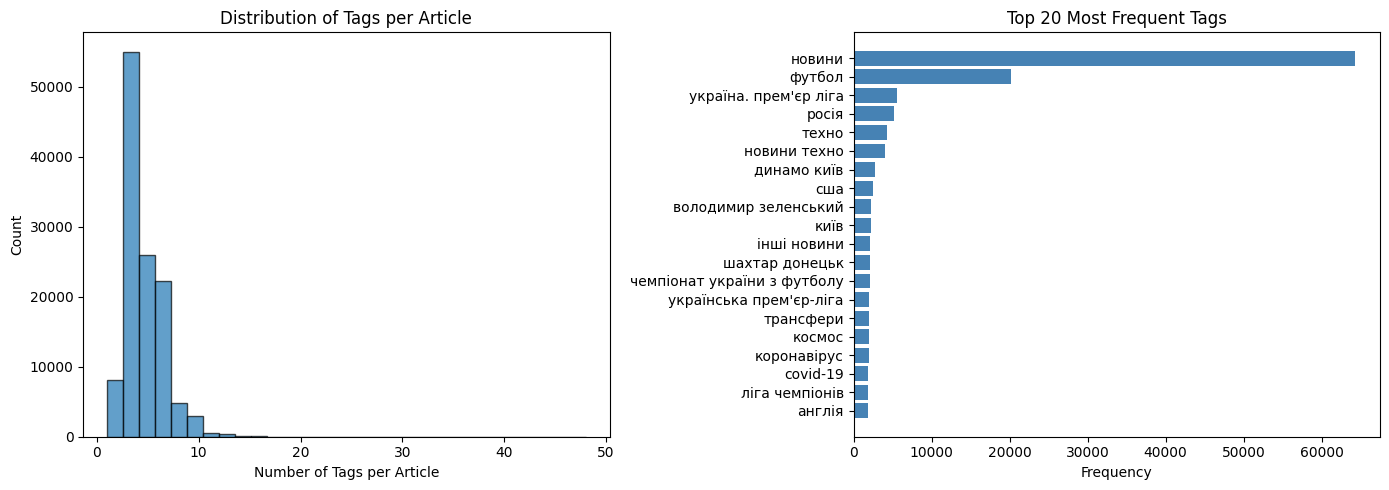

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['n_tags'], bins=30, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Number of Tags per Article')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Tags per Article')

top20 = tag_counts.most_common(20)
axes[1].barh([t[0] for t in top20][::-1], [t[1] for t in top20][::-1], color='steelblue')
axes[1].set_xlabel('Frequency')
axes[1].set_title('Top 20 Most Frequent Tags')

plt.tight_layout()
plt.show()

In [10]:
if TOPIC_COL in df.columns:
    topic_counts = df[TOPIC_COL].value_counts()
    print("Topic distribution:")
    print(topic_counts)
    
    plt.figure(figsize=(10, 5))
    topic_counts.plot(kind='barh', color='coral')
    plt.xlabel('Count')
    plt.title('Articles by Topic')
    plt.tight_layout()
    plt.show()

In [11]:
df['text_len'] = df[TEXT_COL].astype(str).apply(len)
df['title_len'] = df[TITLE_COL].astype(str).apply(len)

print("Text length (chars):")
print(df['text_len'].describe())
print("\nTitle length (chars):")
print(df['title_len'].describe())

Text length (chars):
count    120417.000000
mean       1361.872460
std        1742.901866
min           2.000000
25%         580.000000
50%         896.000000
75%        1438.000000
max       61263.000000
Name: text_len, dtype: float64

Title length (chars):
count    120417.000000
mean         67.456788
std          18.626861
min           2.000000
25%          55.000000
50%          66.000000
75%          77.000000
max         224.000000
Name: title_len, dtype: float64



## 2. Data Preparation

I use **5,000 examples for training** and **1,000 for testing** (as recommended for manageable training time). Articles are truncated to **500 characters** for LLM input.

In [12]:
df_valid = df[df['n_tags'] > 0].reset_index(drop=True)
print(f"Valid articles (with tags): {len(df_valid):,}")

df_valid = df_valid.sample(frac=1, random_state=SEED).reset_index(drop=True)

TRAIN_SIZE = 5000
TEST_SIZE = 1000
MAX_TEXT_LEN = 500

df_train = df_valid.iloc[:TRAIN_SIZE].copy()
df_test = df_valid.iloc[TRAIN_SIZE:TRAIN_SIZE + TEST_SIZE].copy()

print(f" train: {len(df_train)}, Test: {len(df_test)}")
print(f" sample train tags: {df_train['parsed_tags'].iloc[0]}")

Valid articles (with tags): 120,417
 train: 5000, Test: 1000
 sample train tags: ['наука', 'техно', 'новини техно', 'робототехніка']


In [13]:
def truncate_text(text, max_len=MAX_TEXT_LEN):
    text = str(text)
    if len(text) > max_len:
        return text[:max_len] + "..."
    return text


## 3. Evaluation Metrics

The two metrics are used:

**Tag-level F1** — exact match of predicted vs ground truth tags (precision, recall, F1)

**chrF++** — character n-gram overlap, good for morphologically rich Ukrainian

In [14]:
import sacrebleu

def compute_tag_f1(pred_tags_list, true_tags_list):
    total_tp = 0
    total_pred = 0
    total_true = 0
    
    for preds, trues in zip(pred_tags_list, true_tags_list):
        pred_set = set(t.strip().lower() for t in preds if t.strip())
        true_set = set(t.strip().lower() for t in trues if t.strip())
        
        total_tp += len(pred_set & true_set)
        total_pred += len(pred_set)
        total_true += len(true_set)
    
    precision = total_tp / total_pred if total_pred > 0 else 0.0
    recall = total_tp / total_true if total_true > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    
    return {'precision': precision, 'recall': recall, 'f1': f1}


def compute_chrf(pred_tags_list, true_tags_list):

    pred_strings = [' | '.join(preds) for preds in pred_tags_list]
    true_strings = [' | '.join(trues) for trues in true_tags_list]
    
    chrf = sacrebleu.corpus_chrf(pred_strings, [true_strings], word_order=2)
    return chrf.score


def evaluate(pred_tags_list, true_tags_list, method_name="Method"):
    f1_metrics = compute_tag_f1(pred_tags_list, true_tags_list)
    chrf_score = compute_chrf(pred_tags_list, true_tags_list)
    

    print(f"  {method_name} — Results")
    print(f"  Tag-level Precision: {f1_metrics['precision']:.4f}")
    print(f"  Tag-level Recall:    {f1_metrics['recall']:.4f}")
    print(f"  Tag-level F1:        {f1_metrics['f1']:.4f}")
    print(f"  chrF++ Score:        {chrf_score:.2f}")
    
    return {**f1_metrics, 'chrf': chrf_score}

print(" evaluation functions defined.")

 evaluation functions defined.



## 4. Part 1: Classical Baseline — TF-IDF Keyword Extraction

Fit a `TfidfVectorizer` on the training corpus. For each test article, extract the top-N words with the highest TF-IDF scores. These serve as predicted "tags" words that are frequent in the article but rare in the corpus overall.

In [15]:
train_texts = (df_train[TITLE_COL].astype(str) + ' ' + df_train[TEXT_COL].astype(str)).tolist()
test_texts = (df_test[TITLE_COL].astype(str) + ' ' + df_test[TEXT_COL].astype(str)).tolist()

avg_tags = df_train['n_tags'].mean()
TOP_N = max(3, int(round(avg_tags)))
print(f"average tags per article: {avg_tags:.1f} - extracting top-{TOP_N} TF-IDF keywords")

average tags per article: 4.7 - extracting top-5 TF-IDF keywords


In [16]:
tfidf = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2), # unigrams + bigrams
    min_df=2, # appear in at least 2 documents
    max_df=0.95, # ignore terms in >95% of documents
    sublinear_tf=True, # apply log normalization to TF
    strip_accents='unicode',
)

tfidf.fit(train_texts)
print(f"Vocabulary size: {len(tfidf.vocabulary_):,}")

Vocabulary size: 50,000


In [17]:
feature_names = np.array(tfidf.get_feature_names_out()) # extracting top-N TF-IDF keywords for each test article

tfidf_pred_tags = []
test_tfidf_matrix = tfidf.transform(test_texts)

for i in range(len(df_test)):
    row = test_tfidf_matrix[i].toarray().flatten()
    top_indices = row.argsort()[-TOP_N:][::-1]
    top_keywords = feature_names[top_indices].tolist()
    top_keywords = [kw for kw, idx in zip(top_keywords, top_indices) if row[idx] > 0]
    tfidf_pred_tags.append(top_keywords)

for i in range(3):
    print(f" Article {i+1} ---")
    print(f" title: {df_test.iloc[i][TITLE_COL][:100]}...")
    print(f" true tags:      {df_test.iloc[i]['parsed_tags']}")
    print(f" TF-IDF keywords: {tfidf_pred_tags[i]}")

 Article 1 ---
 title:  У Фінській затоці 80 рибалок застрягли на кризі ...
 true tags:      ['рятувальна операція', 'росія', 'новини']
 TF-IDF keywords: ['рибалок', 'метрів', 'шириною', 'рятувальні роботи', 'горе']
 Article 2 ---
 title:  Церемонія запалення олімпійського вогню. НАЖИВО ...
 true tags:      ['олімпіада-2016', 'ріо-2016', 'новини', 'греція', 'олімпійський вогонь']
 TF-IDF keywords: ['запалення', 'наживо', 'церемонію', 'церемонія', 'олімпіиського']
 Article 3 ---
 title: Україна зайняла 2 місце в медальному заліку ЧЄ-2019 зі стрибків у воду...
 true tags:      ['водні види', 'стрибки у воду', 'чемпіонат європи зі стрибків у воду', 'стрибки у воду', 'олексій середа', 'медальний залік']
 TF-IDF keywords: ['медальному заліку', 'медальному', 'стрибках', 'трампліні', 'заліку']


In [18]:
true_tags_test = df_test['parsed_tags'].tolist()
tfidf_results = evaluate(tfidf_pred_tags, true_tags_test, "TF-IDF Baseline")

  TF-IDF Baseline — Results
  Tag-level Precision: 0.0620
  Tag-level Recall:    0.0653
  Tag-level F1:        0.0636
  chrF++ Score:        21.29


### Analysis: TF-IDF Baseline

TF-IDF can only extract words that **literally appear** in the article text. It cannot generate abstract or generalized tags (e.g., a tag like "політика" won't appear unless that exact word is in the text). This is the fundamental limitation of extractive methods — they're bounded by the vocabulary of each individual document.


## 5. Part 2: Zero-Shot LLM — Qwen 2.5 3B via Unsloth

I load Qwen 2.5 3B using Unsloth (4-bit quantization to fit 16GB GPU) and use a designed Ukrainian prompt to generate tags without any fine-tuning.

In [19]:
from unsloth import FastLanguageModel
import torch

MODEL_NAME = "unsloth/Qwen2.5-3B-Instruct"
MAX_SEQ_LENGTH = 1024

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=MODEL_NAME,
    max_seq_length=MAX_SEQ_LENGTH,
    dtype=None,         
    load_in_4bit=True,
)

print(f"Model loaded: {MODEL_NAME}")
print(f"GPU memory used: {torch.cuda.memory_allocated() / 1e9:.2f} GB")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.4.6: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/2.36G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/271 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/605 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

unsloth/qwen2.5-3b-instruct-unsloth-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.
Model loaded: unsloth/Qwen2.5-3B-Instruct
GPU memory used: 2.40 GB


In [20]:
TAG_PROMPT_TEMPLATE = """Ти — система для генерації тегів новинних статей українською мовою.

Для наданої статті згенеруй від 3 до 7 інформативних тегів, що описують основні теми та сутності статті.
Теги мають бути короткими (1-3 слова), інформативними та розділеними символом |.

Заголовок: {title}
Текст: {text}

Теги:"""

In [21]:
def build_prompt(title, text):
    return TAG_PROMPT_TEMPLATE.format(
        title=str(title),
        text=truncate_text(str(text), MAX_TEXT_LEN)
    )

sample_prompt = build_prompt(df_test.iloc[0][TITLE_COL], df_test.iloc[0][TEXT_COL])
print(sample_prompt[:500])

Ти — система для генерації тегів новинних статей українською мовою.

Для наданої статті згенеруй від 3 до 7 інформативних тегів, що описують основні теми та сутності статті.
Теги мають бути короткими (1-3 слова), інформативними та розділеними символом |.

Заголовок:  У Фінській затоці 80 рибалок застрягли на кризі 
Текст: Про це передає "РИА Новости". Уздовж берега утворилася тріщина довжиною близько 300 метрів і шириною від 7 до 15 метрів. В цей час на льоду знаходилися дві групи рибалок-любите


In [22]:
def parse_model_tags(output_text):
  
    first_line = output_text.strip().split('\n')[0]
    
    if '|' in first_line:
        tags = first_line.split('|')
    elif ',' in first_line:
        tags = first_line.split(',')
    else:
        tags = [first_line]
    
    cleaned = []
    for tag in tags:
        tag = tag.strip()
        tag = re.sub(r'^[\d]+[\.\)\-]\s*', '', tag)
        tag = re.sub(r'^[\-\*\•]\s*', '', tag)
        tag = tag.strip(' \t\n\r"\'')
        tag = tag.lower()
        if tag and len(tag) > 1:
            cleaned.append(tag)
    
    return cleaned[:10]

print("done")

done


In [23]:
FastLanguageModel.for_inference(model)

zeroshot_pred_tags = []

for i in tqdm(range(len(df_test)), desc="Zero-shot inference"):
    row = df_test.iloc[i]
    prompt = build_prompt(row[TITLE_COL], row[TEXT_COL])
    
    messages = [
        {"role": "user", "content": prompt}
    ]
    
    input_text = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    inputs = tokenizer(input_text, return_tensors="pt").to(model.device)
    
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=128,
            temperature=0.1,
            top_p=0.9,
            do_sample=True,
            repetition_penalty=1.2,
        )
    
    generated = tokenizer.decode(outputs[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True)
    tags = parse_model_tags(generated)
    zeroshot_pred_tags.append(tags)
    
    if i < 3:
        print(f" Article {i+1} ---")
        print(f" title: {row[TITLE_COL][:80]}...")
        print(f" raw output: {generated[:200]}")
        print(f" parsed tags: {tags}")
        print(f" true tags:   {row['parsed_tags']}")

Zero-shot inference:   0%|          | 0/1000 [00:00<?, ?it/s]

Both `max_new_tokens` (=128) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=128) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


 Article 1 ---
 title:  У Фінській затоці 80 рибалок застрягли на кризі ...
 raw output: Ударний аварійний катер|Безпека водного туризму|Криза на водохладі|Рыбаків спасли|Ледова трещина|Громадна авариjsкая палуба
 parsed tags: ['ударний аварійний катер', 'безпека водного туризму', 'криза на водохладі', 'рыбаків спасли', 'ледова трещина', 'громадна авариjsкая палуба']
 true tags:   ['рятувальна операція', 'росія', 'новини']


Both `max_new_tokens` (=128) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


 Article 2 ---
 title:  Церемонія запалення олімпійського вогню. НАЖИВО ...
 raw output: олимпійська_циреномонія|огневий_вогень|МОК_трнетрибуцияncyi_vogeni_zapalennya_|олимпіада_2024
 parsed tags: ['олимпійська_циреномонія', 'огневий_вогень', 'мок_трнетрибуцияncyi_vogeni_zapalennya_', 'олимпіада_2024']
 true tags:   ['олімпіада-2016', 'ріо-2016', 'новини', 'греція', 'олімпійський вогонь']


Both `max_new_tokens` (=128) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


 Article 3 ---
 title: Україна зайняла 2 місце в медальному заліку ЧЄ-2019 зі стрибків у воду...
 raw output: украина|чемпионат|медали|стробки|синхроністики|трamplin|вищий
 parsed tags: ['украина', 'чемпионат', 'медали', 'стробки', 'синхроністики', 'трamplin', 'вищий']
 true tags:   ['водні види', 'стрибки у воду', 'чемпіонат європи зі стрибків у воду', 'стрибки у воду', 'олексій середа', 'медальний залік']


Both `max_new_tokens` (=128) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=128) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=128) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=128) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_gene

In [25]:
zeroshot_results = evaluate(zeroshot_pred_tags, true_tags_test, "Zero-Shot Qwen 2.5 3B")

  Zero-Shot Qwen 2.5 3B — Results
  Tag-level Precision: 0.0642
  Tag-level Recall:    0.0796
  Tag-level F1:        0.0711
  chrF++ Score:        22.01


### Analysis: Zero-Shot LLM

The zero-shot LLM can generate **abstractive** tags, tags that don't appear verbatim in the text. It understands the semantic content and can generate relevant topics. However, without fine-tuning, the model may not match the **specific style and vocabulary** of the human-assigned tags in this dataset.


## 6. Part 3: Fine-Tuned LLM with LoRA

I now fine-tune the same Qwen 2.5 3B model using LoRA adapters on our training set, then evaluate on the same test set.

In [26]:
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=MODEL_NAME,
    max_seq_length=MAX_SEQ_LENGTH,
    dtype=None,
    load_in_4bit=True,
)

model = FastLanguageModel.get_peft_model(
    model,
    r=16, # LoRA rank
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj",
                    "gate_proj", "up_proj", "down_proj"],
    lora_alpha=16,
    lora_dropout=0,               
    bias="none",
    use_gradient_checkpointing="unsloth",
    random_state=SEED,
)

model.print_trainable_parameters()

==((====))==  Unsloth 2026.4.6: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

unsloth/qwen2.5-3b-instruct-unsloth-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


Unsloth 2026.4.6 patched 36 layers with 36 QKV layers, 36 O layers and 36 MLP layers.


trainable params: 29,933,568 || all params: 3,115,872,256 || trainable%: 0.9607


In [27]:
EOS_TOKEN = tokenizer.eos_token

def format_training_example(row):

    title = str(row[TITLE_COL])
    text = truncate_text(str(row[TEXT_COL]), MAX_TEXT_LEN)
    tags_str = ' | '.join(row['parsed_tags'])
    
    messages = [
        {"role": "user", "content": build_prompt(title, text)},
        {"role": "assistant", "content": tags_str}
    ]
    
    formatted = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=False
    )
    return formatted + EOS_TOKEN

train_texts_formatted = []
for idx in tqdm(range(len(df_train)), desc="Formatting training data"):
    train_texts_formatted.append(format_training_example(df_train.iloc[idx]))

print(f" Formatted {len(train_texts_formatted)} training examples")
print(f"\n sample formatted example:")
print(train_texts_formatted[0][:600])

Formatting training data:   0%|          | 0/5000 [00:00<?, ?it/s]

 Formatted 5000 training examples

 sample formatted example:
<|im_start|>system
You are Qwen, created by Alibaba Cloud. You are a helpful assistant.<|im_end|>
<|im_start|>user
Ти — система для генерації тегів новинних статей українською мовою.

Для наданої статті згенеруй від 3 до 7 інформативних тегів, що описують основні теми та сутності статті.
Теги мають бути короткими (1-3 слова), інформативними та розділеними символом |.

Заголовок: Юристи задумались над законодавчим регулюванням секс-роботів
Текст: Двоє юристів з Австралії вважають, що зовсім скоро нам знадобляться нові правові норми й закони, які будуть регулювати діяльність секс-машин. Такі вже


In [28]:
from datasets import Dataset as HFDataset

train_dataset = HFDataset.from_dict({"text": train_texts_formatted})
print(f"Training dataset: {train_dataset}")

Training dataset: Dataset({
    features: ['text'],
    num_rows: 5000
})


In [31]:
from trl import SFTTrainer, SFTConfig
import torch
import types

def _fixed_training_step(self, model, inputs, num_items_in_batch=None):
    model.train()
    inputs = self._prepare_inputs(inputs)
    with self.compute_loss_context_manager():
        loss = self.compute_loss(model, inputs, num_items_in_batch=num_items_in_batch)
    if self.args.n_gpu > 1:
        loss = loss.mean()
    self.accelerator.backward(loss)
    return loss.detach() / self.args.gradient_accumulation_steps

import unsloth.models._utils as _unsloth_utils
_unsloth_utils._unsloth_training_step = _fixed_training_step
from transformers import Trainer
Trainer.training_step = _fixed_training_step

sft_config = SFTConfig(
    output_dir="./lora_output",
    per_device_train_batch_size=4,
    gradient_accumulation_steps=4,
    num_train_epochs=1,
    learning_rate=2e-4,
    lr_scheduler_type="cosine",
    warmup_ratio=0.05,
    weight_decay=0.01,
    logging_steps=25,
    save_strategy="no",
    fp16=not torch.cuda.is_bf16_supported(),
    bf16=torch.cuda.is_bf16_supported(),
    optim="adamw_8bit",
    seed=SEED,
    report_to="none",
    dataset_text_field="text",
    max_seq_length=MAX_SEQ_LENGTH,
    packing=False,
)

trainer = SFTTrainer(
    model=model,
    processing_class=tokenizer,
    train_dataset=train_dataset,
    args=sft_config,
)

trainer.training_step = types.MethodType(_fixed_training_step, trainer)
print("Trainer ready.")

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Unsloth: Tokenizing ["text"] (num_proc=8):   0%|          | 0/5000 [00:00<?, ? examples/s]

🦥 Unsloth: Padding-free auto-enabled, enabling faster training.
Trainer ready.


In [32]:

trainer_stats = trainer.train()

print(f"\nTraining completed!")
print(f"  Total steps: {trainer_stats.global_step}")
print(f"  Training loss: {trainer_stats.training_loss:.4f}")
print(f"  Training time: {trainer_stats.metrics['train_runtime']:.0f} seconds")

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 5,000 | Num Epochs = 1 | Total steps = 313
O^O/ \_/ \    Batch size per device = 4 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (4 x 4 x 1) = 16
 "-____-"     Trainable parameters = 29,933,568 of 3,115,872,256 (0.96% trained)
`use_return_dict` is deprecated! Use `return_dict` instead!


Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss
25,0.403432
50,0.275109
75,0.267148
100,0.260128
125,0.258063
150,0.252769
175,0.249799
200,0.247202
225,0.248572
250,0.243069



Training completed!
  Total steps: 313
  Training loss: 0.2650
  Training time: 2887 seconds


In [34]:
LORA_SAVE_PATH = "/kaggle/working/lora_ua_news_tags"

model.save_pretrained(LORA_SAVE_PATH)
tokenizer.save_pretrained(LORA_SAVE_PATH)

print(f"LoRA adapter saved to: {LORA_SAVE_PATH}")
!ls -lh {LORA_SAVE_PATH}/

LoRA adapter saved to: /kaggle/working/lora_ua_news_tags
total 126M
-rw-r--r-- 1 root root 1.2K Apr 17 20:01 adapter_config.json
-rw-r--r-- 1 root root 115M Apr 17 20:01 adapter_model.safetensors
-rw-r--r-- 1 root root 2.5K Apr 17 20:01 chat_template.jinja
-rw-r--r-- 1 root root 2.0K Apr 17 19:00 config.json
-rw-r--r-- 1 root root  265 Apr 17 19:00 generation_config.json
-rw-r--r-- 1 root root 5.2K Apr 17 20:01 README.md
-rw-r--r-- 1 root root  374 Apr 17 20:01 tokenizer_config.json
-rw-r--r-- 1 root root  11M Apr 17 20:01 tokenizer.json


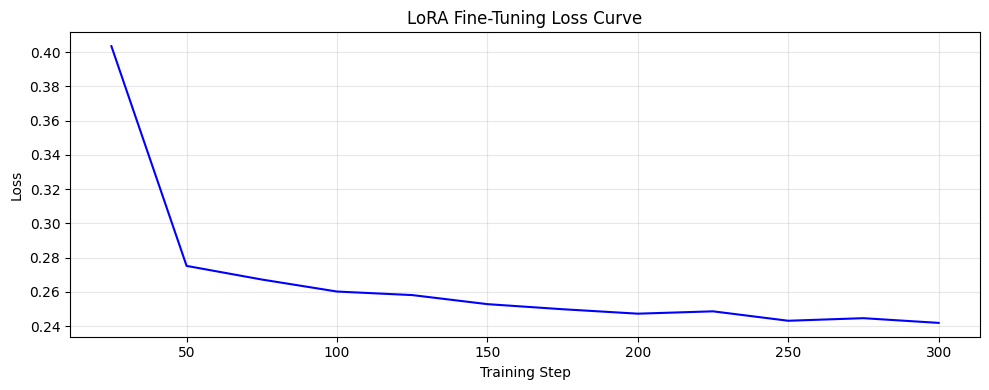

In [35]:
log_history = trainer.state.log_history
train_losses = [(entry['step'], entry['loss']) for entry in log_history if 'loss' in entry]

if train_losses:
    steps, losses = zip(*train_losses)
    plt.figure(figsize=(10, 4))
    plt.plot(steps, losses, 'b-', linewidth=1.5)
    plt.xlabel('Training Step')
    plt.ylabel('Loss')
    plt.title('LoRA Fine-Tuning Loss Curve')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [36]:
FastLanguageModel.for_inference(model)

finetuned_pred_tags = []

for i in tqdm(range(len(df_test)), desc="Fine-tuned inference"):
    row = df_test.iloc[i]
    prompt = build_prompt(row[TITLE_COL], row[TEXT_COL])
    
    messages = [
        {"role": "user", "content": prompt}
    ]
    
    input_text = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    inputs = tokenizer(input_text, return_tensors="pt").to(model.device)
    
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=128,
            temperature=0.1,
            top_p=0.9,
            do_sample=True,
            repetition_penalty=1.2,
        )
    
    generated = tokenizer.decode(outputs[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True)
    tags = parse_model_tags(generated)
    finetuned_pred_tags.append(tags)
    
    if i < 3:
        print(f"\n--- Article {i+1} ---")
        print(f"Title: {row[TITLE_COL][:80]}...")
        print(f"Raw output: {generated[:200]}")
        print(f"Parsed tags: {tags}")
        print(f"True tags:   {row['parsed_tags']}")

Fine-tuned inference:   0%|          | 0/1000 [00:00<?, ?it/s]

Both `max_new_tokens` (=128) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=128) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



--- Article 1 ---
Title:  У Фінській затоці 80 рибалок застрягли на кризі ...
Raw output: фінска затока | рятування | новини | фінландия
Parsed tags: ['фінска затока', 'рятування', 'новини', 'фінландия']
True tags:   ['рятувальна операція', 'росія', 'новини']


Both `max_new_tokens` (=128) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



--- Article 2 ---
Title:  Церемонія запалення олімпійського вогню. НАЖИВО ...
Raw output: олимпийське спорту | олімпіада | олімпійська святта | олімпійський вогень
Parsed tags: ['олимпийське спорту', 'олімпіада', 'олімпійська святта', 'олімпійський вогень']
True tags:   ['олімпіада-2016', 'ріо-2016', 'новини', 'греція', 'олімпійський вогонь']


Both `max_new_tokens` (=128) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



--- Article 3 ---
Title: Україна зайняла 2 місце в медальному заліку ЧЄ-2019 зі стрибків у воду...
Raw output: стрібки у воді | че-2019 | спорт | незабаром
Parsed tags: ['стрібки у воді', 'че-2019', 'спорт', 'незабаром']
True tags:   ['водні види', 'стрибки у воду', 'чемпіонат європи зі стрибків у воду', 'стрибки у воду', 'олексій середа', 'медальний залік']


Both `max_new_tokens` (=128) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=128) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=128) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=128) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_gene

In [37]:
finetuned_results = evaluate(finetuned_pred_tags, true_tags_test, "Fine-Tuned Qwen 2.5 3B (LoRA)")

  Fine-Tuned Qwen 2.5 3B (LoRA) — Results
  Tag-level Precision: 0.2836
  Tag-level Recall:    0.3354
  Tag-level F1:        0.3073
  chrF++ Score:        39.15


---
## 7. Comparison of All Three Approaches

In [38]:
results_df = pd.DataFrame({
    'Method': ['TF-IDF Baseline', 'Zero-Shot Qwen 2.5 3B', 'Fine-Tuned Qwen 2.5 3B (LoRA)'],
    'Precision': [tfidf_results['precision'], zeroshot_results['precision'], finetuned_results['precision']],
    'Recall': [tfidf_results['recall'], zeroshot_results['recall'], finetuned_results['recall']],
    'F1': [tfidf_results['f1'], zeroshot_results['f1'], finetuned_results['f1']],
    'chrF++': [tfidf_results['chrf'], zeroshot_results['chrf'], finetuned_results['chrf']],
})

results_styled = results_df.copy()
for col in ['Precision', 'Recall', 'F1']:
    results_styled[col] = results_styled[col].apply(lambda x: f"{x:.4f}")
results_styled['chrF++'] = results_styled['chrF++'].apply(lambda x: f"{x:.2f}")


print("        FINAL COMPARISON: All Three Approaches")
print(results_styled.to_string(index=False))

        FINAL COMPARISON: All Three Approaches
                       Method Precision Recall     F1 chrF++
              TF-IDF Baseline    0.0620 0.0653 0.0636  21.29
        Zero-Shot Qwen 2.5 3B    0.0642 0.0796 0.0711  22.01
Fine-Tuned Qwen 2.5 3B (LoRA)    0.2836 0.3354 0.3073  39.15


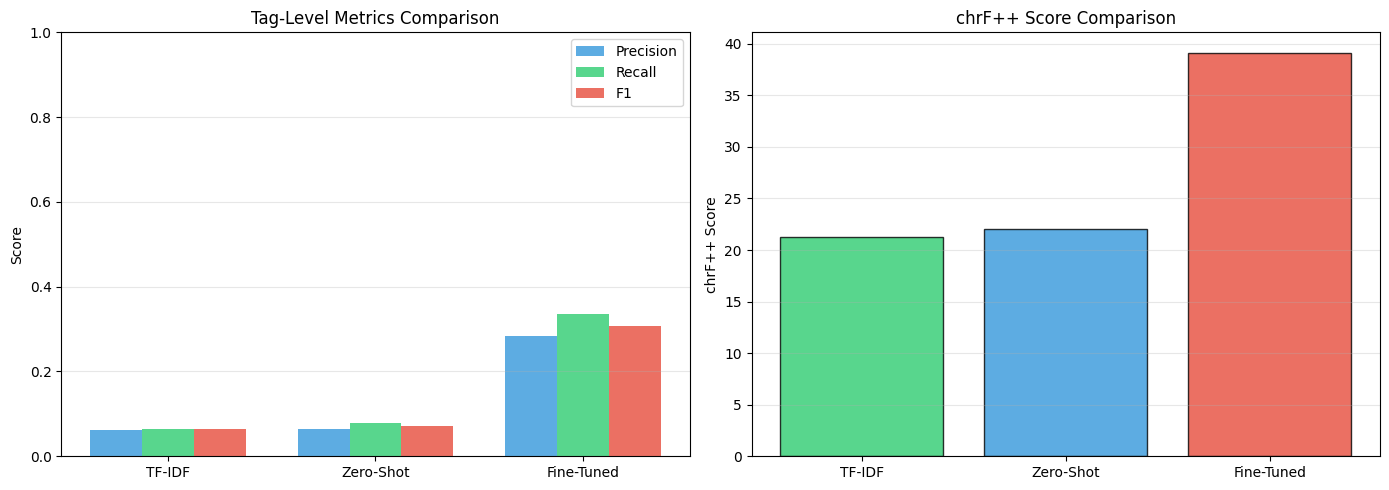

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

methods = ['TF-IDF', 'Zero-Shot', 'Fine-Tuned']
colors = ['#2ecc71', '#3498db', '#e74c3c']

x = np.arange(len(methods))
width = 0.25

axes[0].bar(x - width, results_df['Precision'], width, label='Precision', color='#3498db', alpha=0.8)
axes[0].bar(x, results_df['Recall'], width, label='Recall', color='#2ecc71', alpha=0.8)
axes[0].bar(x + width, results_df['F1'], width, label='F1', color='#e74c3c', alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(methods)
axes[0].set_ylabel('Score')
axes[0].set_title('Tag-Level Metrics Comparison')
axes[0].legend()
axes[0].set_ylim(0, 1)
axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(methods, results_df['chrF++'], color=colors, alpha=0.8, edgecolor='black')
axes[1].set_ylabel('chrF++ Score')
axes[1].set_title('chrF++ Score Comparison')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [40]:
print("QUALITATIVE COMPARISON: Sample Predictions")

for i in range(5):
    row = df_test.iloc[i]
    print(f"\n Article {i+1} ---")
    print(f"Title:      {str(row[TITLE_COL])[:100]}")
    print(f"True tags:  {row['parsed_tags']}")
    print(f"TF-IDF:     {tfidf_pred_tags[i]}")
    print(f"Zero-shot:  {zeroshot_pred_tags[i]}")
    print(f"Fine-tuned: {finetuned_pred_tags[i]}")

QUALITATIVE COMPARISON: Sample Predictions

 Article 1 ---
Title:       У Фінській затоці 80 рибалок застрягли на кризі 
True tags:  ['рятувальна операція', 'росія', 'новини']
TF-IDF:     ['рибалок', 'метрів', 'шириною', 'рятувальні роботи', 'горе']
Zero-shot:  ['ударний аварійний катер', 'безпека водного туризму', 'криза на водохладі', 'рыбаків спасли', 'ледова трещина', 'громадна авариjsкая палуба']
Fine-tuned: ['фінска затока', 'рятування', 'новини', 'фінландия']

 Article 2 ---
Title:       Церемонія запалення олімпійського вогню. НАЖИВО 
True tags:  ['олімпіада-2016', 'ріо-2016', 'новини', 'греція', 'олімпійський вогонь']
TF-IDF:     ['запалення', 'наживо', 'церемонію', 'церемонія', 'олімпіиського']
Zero-shot:  ['олимпійська_циреномонія', 'огневий_вогень', 'мок_трнетрибуцияncyi_vogeni_zapalennya_', 'олимпіада_2024']
Fine-tuned: ['олимпийське спорту', 'олімпіада', 'олімпійська святта', 'олімпійський вогень']

 Article 3 ---
Title:      Україна зайняла 2 місце в медальному заліку ЧЄ